In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")
schema = pd.read_sql("PRAGMA table_info(checker);", conn)

print(schema)

   cid       name       type  notnull dflt_value  pk
0    0      index    INTEGER        0       None   0
1    1     status       TEXT        0       None   0
2    2    success    INTEGER        0       None   0
3    3  timestamp  TIMESTAMP        0       None   0
4    4  numTrials    INTEGER        0       None   0
5    5    labname       TEXT        0       None   0
6    6        uid       TEXT        0       None   0


In [3]:
df = pd.read_sql_query(
    '''
    SELECT timestamp AS commits
    FROM checker
    WHERE uid LIKE 'user_%'
    ''',
    conn,
    parse_dates=['commits'],
)

In [4]:
filt = df['commits'].dt.dayofweek > 4

weekend_commits = df[filt]['commits'].dt.hour
working_day_commits = df[~filt]['commits'].dt.hour

In [5]:
print("Values for working days:", working_day_commits.shape[0])
print("Values for weekend days:", weekend_commits.shape[0])

Values for working days: 2037
Values for weekend days: 1170


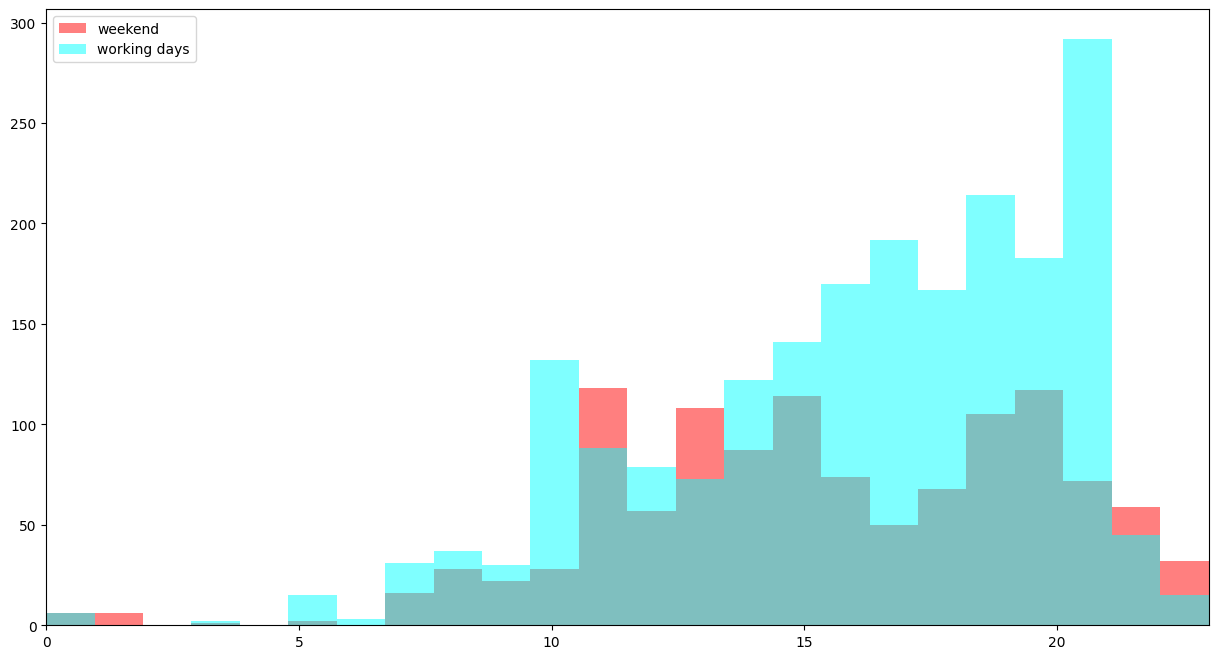

In [6]:
plt.figure(figsize=(15, 8))
plt.hist(weekend_commits,
         bins=24,
         label='weekend',
         color='red',
         alpha=0.5)

plt.hist(working_day_commits,
         bins=24,
         label='working days',
         color='cyan',
         alpha=0.5)
         
plt.xlim(0, 23)
plt.legend()
plt.show()

Are there hours when the total number of commits was higher on weekends than on working days? 11, 13, 22, 23.

In [7]:
conn.close()